In [8]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("//content/sample_data/Atlantic_United_States.csv")
# ==========================================
# DISPLAY DATA
# ==========================================

print("\nFIRST 5 ROWS\n")

print(df.head())

# ==========================================
# DATASET INFO
# ==========================================

print("\nDATASET INFO\n")

print(df.info())

# ==========================================
# MISSING VALUES
# ==========================================

print("\nMISSING VALUES\n")

print(df.isnull().sum())

# ==========================================
# DUPLICATES
# ==========================================

print("\nDUPLICATES\n")

print(df.duplicated().sum())


FIRST 5 ROWS

         date  position                         song  \
0  18-05-2024         1              Ella Baila Sola   
1  18-05-2024         2                   Last Night   
2  18-05-2024         3  All My Life (feat. J. Cole)   
3  18-05-2024         4                    un x100to   
4  18-05-2024         5                    Kill Bill   

                       artist  popularity  duration_ms album_type  \
0              Eslabon Armado          89       165671      album   
1               Morgan Wallen          89       163854      album   
2          Lil Durk & J. Cole          84       223878     single   
3  Grupo Frontera & Bad Bunny          99       194563     single   
4                         SZA          94       153946      album   

   total_tracks  is_explicit  \
0            16        False   
1            36         True   
2             1         True   
3             1        False   
4            23        False   

                                     alb

In [9]:
# ==========================================
# CONVERT DATE COLUMN
# ==========================================

df['date'] = pd.to_datetime(
    df['date'],
    dayfirst=True
)

# ==========================================
# REMOVE DUPLICATES
# ==========================================

df = df.drop_duplicates()

# ==========================================
# VALIDATE RANK RANGE
# ==========================================

df = df[
    (df['position'] >= 1) &
    (df['position'] <= 50)
]

# ==========================================
# CREATE DURATION IN MINUTES
# ==========================================

df['duration_min'] = (
    df['duration_ms'] / 60000
)

# ==========================================
# CHECK CLEANED DATA
# ==========================================

print(df.head())

# ==========================================
# FINAL SHAPE
# ==========================================

print("\nFINAL DATASET SHAPE")

print(df.shape)

# ==========================================
# DUPLICATE CHECK
# ==========================================

print("\nDUPLICATES AFTER CLEANING")

print(df.duplicated().sum())

        date  position                         song  \
0 2024-05-18         1              Ella Baila Sola   
1 2024-05-18         2                   Last Night   
2 2024-05-18         3  All My Life (feat. J. Cole)   
3 2024-05-18         4                    un x100to   
4 2024-05-18         5                    Kill Bill   

                       artist  popularity  duration_ms album_type  \
0              Eslabon Armado          89       165671      album   
1               Morgan Wallen          89       163854      album   
2          Lil Durk & J. Cole          84       223878     single   
3  Grupo Frontera & Bad Bunny          99       194563     single   
4                         SZA          94       153946      album   

   total_tracks  is_explicit  \
0            16        False   
1            36         True   
2             1         True   
3             1        False   
4            23        False   

                                     album_cover_url  duratio

FEATURE ENGINEERNG

In [10]:

days_chart = (
    df.groupby('song')['date']
    .nunique()
    .reset_index(name='days_on_chart'))

print("\nDAYS ON CHART\n")

print(days_chart.head())

#average rank

avg_rank = (
    df.groupby('song')['position']
    .mean()
    .reset_index(name='average_rank'))

print("\nAVERAGE RANK\n")

print(avg_rank.head())

#best rank

best_rank = (
    df.groupby('song')['position']
    .min()
    .reset_index(name='best_rank'))

print("\nBEST RANK\n")

print(best_rank.head())


volatility = (
    df.groupby('song')['position']
    .std()
    .reset_index(name='rank_volatility'))

print("\nRANK VOLATILITY\n")

print(volatility.head())

#popularity trend
df['popularity_trend'] = (
    df.groupby('song')['popularity']
    .transform(
        lambda x: x.rolling(7, min_periods=1).mean() ))

print("\nPOPULARITY TREND CREATED")


DAYS ON CHART

                                                song  days_on_chart
0        "Slut!" (Taylor's Version) (From The Vault)             26
1                            (Don't Fear) The Reaper              1
2  (There's No Place Like) Home for the Holidays ...              2
3                                       16 CARRIAGES             10
4                                            2 hands              7

AVERAGE RANK

                                                song  average_rank
0        "Slut!" (Taylor's Version) (From The Vault)     15.500000
1                            (Don't Fear) The Reaper     50.000000
2  (There's No Place Like) Home for the Holidays ...     45.000000
3                                       16 CARRIAGES     26.000000
4                                            2 hands     33.571429

BEST RANK

                                                song  best_rank
0        "Slut!" (Taylor's Version) (From The Vault)          3
1                  

POPULARITY DISTRIBUTION

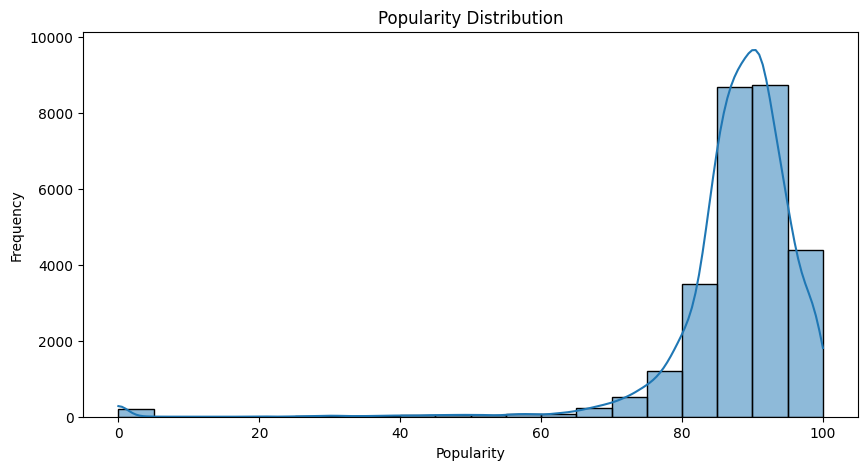

In [11]:

plt.figure(figsize=(10,5))

sns.histplot(
    df['popularity'],
    bins=20,
    kde=True)

plt.title("Popularity Distribution")

plt.xlabel("Popularity")

plt.ylabel("Frequency")

plt.show()

The histogram of popularity scores shows a highly concentrated distribution between popularity scores of 80 and 100, indicating that most songs appearing in the United States Top 50 playlist already possess high popularity levels.The majority of observations cluster toward higher popularity values with relatively fewer low-popularity songs.

POPULARITY V/S RANK

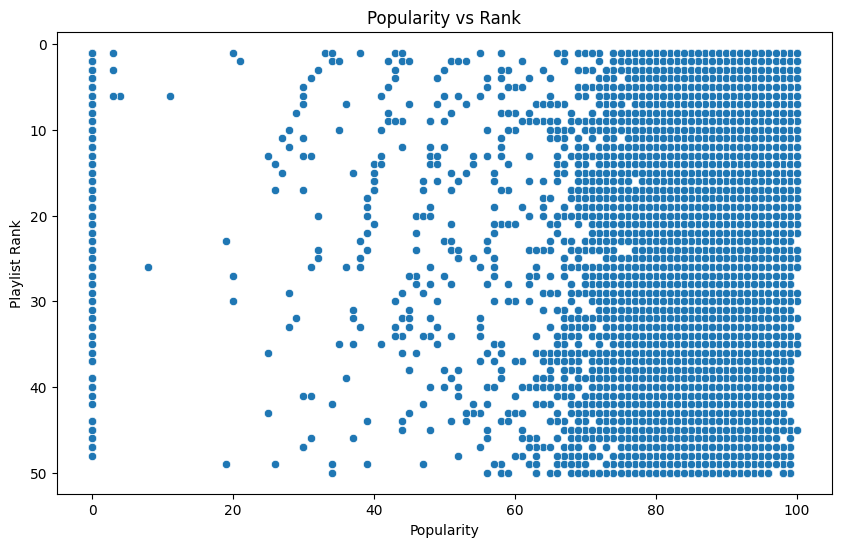

In [12]:

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='popularity',
    y='position',
    data=df)

# Reverse rank axis
plt.gca().invert_yaxis()

plt.title("Popularity vs Rank")

plt.xlabel("Popularity")

plt.ylabel("Playlist Rank")

plt.show()

The scatter plot between popularity and playlist rank demonstrates a moderate inverse relationship between the two variables. Songs with higher popularity scores tend to occupy better playlist positions.The observed pattern suggests a negative correlation because lower numerical ranks correspond to better playlist positions.

In [ ]:
EXPLICIT V/S NON-EXPLICIT ANALYSIS


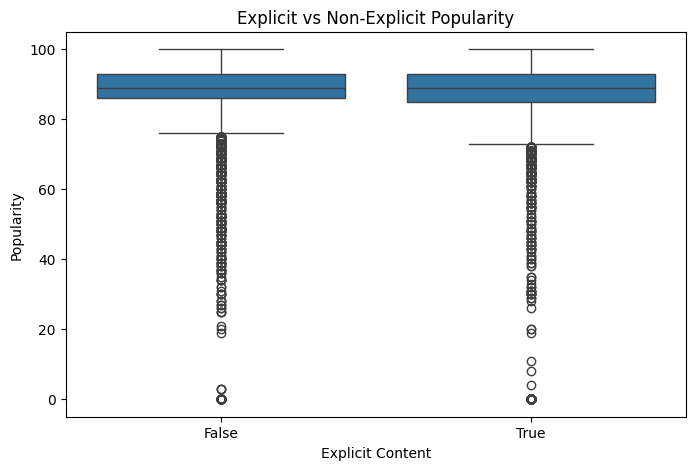

In [13]:

plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_explicit',
    y='popularity',
    data=df)

plt.title("Explicit vs Non-Explicit Popularity")

plt.xlabel("Explicit Content")

plt.ylabel("Popularity")

plt.show()

The boxplot comparison between explicit and non-explicit songs indicates that both categories exhibit highly similar popularity distributions. Median popularity scores are nearly identical, and the interquartile ranges substantially overlap.
Both distributions contain several lower-popularity outliers, indicating occasional poor-performing tracks in both content categories. However, there is no strong statistical evidence suggesting that explicit content significantly increases or decreases popularity.

ARTIST DOMINANCE

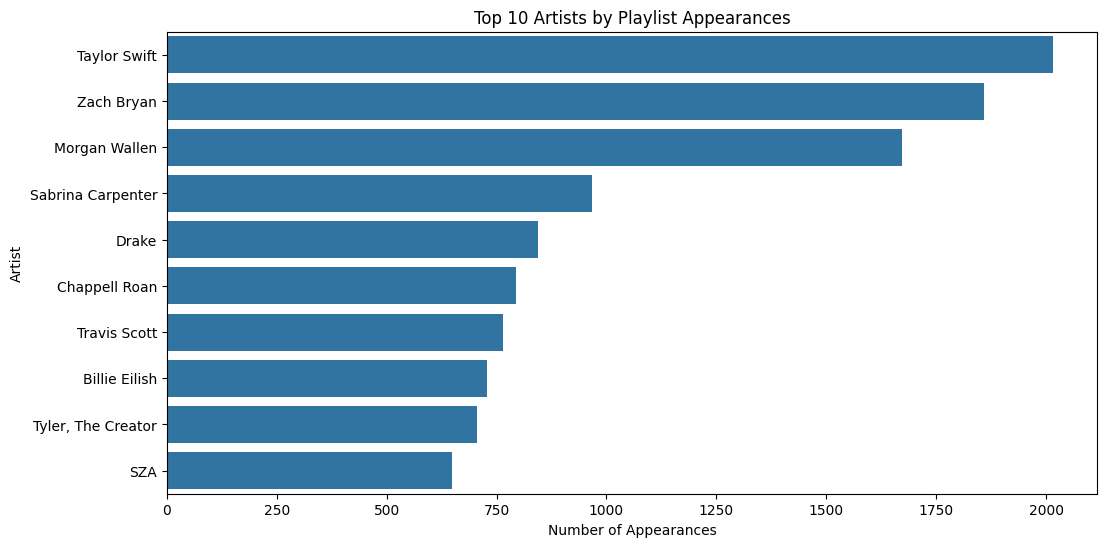

In [14]:

artist_counts = (
    df['artist']
    .value_counts()
    .head(10))

plt.figure(figsize=(12,6))

sns.barplot(
    x=artist_counts.values,
    y=artist_counts.index)

plt.title("Top 10 Artists by Playlist Appearances")

plt.xlabel("Number of Appearances")

plt.ylabel("Artist")

plt.show()

:The artist dominance analysis reveals substantial inequality in playlist representation among artists. Taylor Swift, Zach Bryan, and Morgan Wallen exhibit significantly higher playlist appearances compared to other artists, indicating strong market concentration.The large differences between artists indicate non-uniform representation across the playlist ecosystem.

RANK TREND ANALYSIS

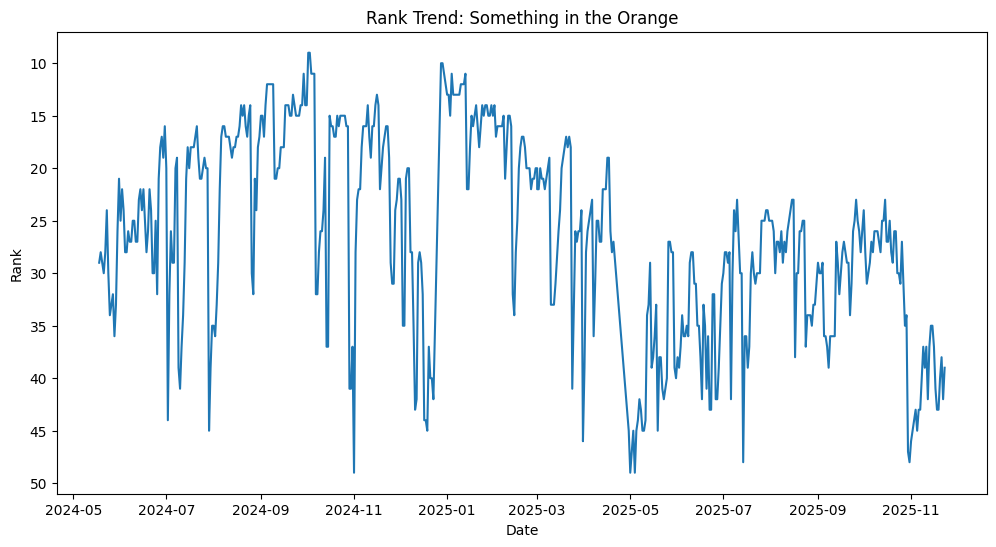

In [15]:

top_song = (
    df['song']
    .value_counts()
    .index[0])

song_df = df[
    df['song'] == top_song]

plt.figure(figsize=(12,6))

plt.plot(
    song_df['date'],
    song_df['position'])

plt.gca().invert_yaxis()

plt.title(f"Rank Trend: {top_song}")

plt.xlabel("Date")

plt.ylabel("Rank")

plt.show()

The time-series plot of playlist rank demonstrates substantial rank fluctuations over time, indicating dynamic playlist movement behavior. The song exhibits both upward and downward rank transitions, suggesting varying listener engagement intensity throughout the observation period.

The time-series plot of playlist rank demonstrates substantial rank fluctuations over time, indicating dynamic playlist movement behavior. The song exhibits both upward and downward rank transitions, suggesting varying listener engagement intensity throughout the observation period.

CORRELATION MATRIX

              position  popularity  duration_ms  total_tracks  duration_min
position      1.000000   -0.094528    -0.044681      0.116385     -0.044681
popularity   -0.094528    1.000000    -0.043326     -0.182466     -0.043326
duration_ms  -0.044681   -0.043326     1.000000      0.042254      1.000000
total_tracks  0.116385   -0.182466     0.042254      1.000000      0.042254
duration_min -0.044681   -0.043326     1.000000      0.042254      1.000000


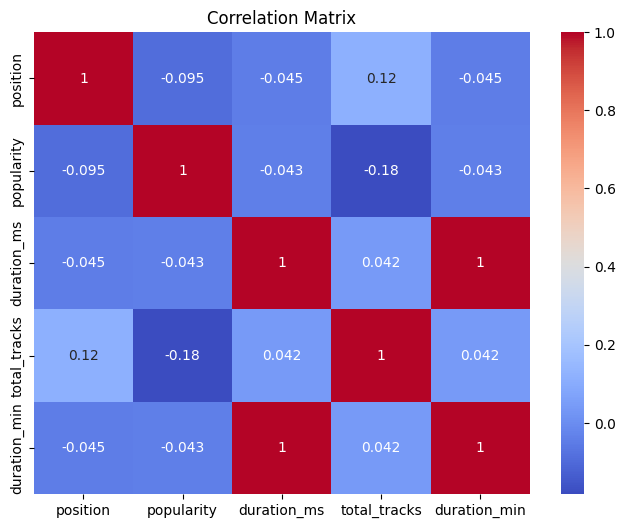

In [16]:
# ==========================================
# CORRELATION MATRIX
# ==========================================

correlation_data = df[[
    'position',
    'popularity',
    'duration_ms',
    'total_tracks',
    'duration_min'
]]

correlation_matrix = correlation_data.corr()

print(correlation_matrix)

# ==========================================
# HEATMAP
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

Position V/S popularity       
A weak negative correlation exists between playlist position and popularity.indicates that, songs with higher popularity scores tend to achieve better playlist ranks but the relationship is relatively wweak.Because playlist ranking is inverse,
smaller rank numbers indicate better positions

position V/S total tracks   
A weak positive relationship exists between playlist position and album size.this suggest that songs from albums with more tracks may slightly occupy lower-ranked positions on average and album size has limited influence on playlist success

popularuty v/s total tracks     
A weak negative relationship exists between popularity and album track count.This indicate that songs originating from smaller albums or singles tend to achieve slightly higher popularity scores.

Popularity v/s Duration
The relationship between song duration and popularity is extremely weak.This suggest that  song length has negligible influence on popularity performance and both short and long songs can succeed equally. so,duration alone is not a strong determinant of streaming success.

Duration_ms vs Duration_min   
A perfect positive correlation exists because,duration in minutes is directly derived from duration in milliseconds

CONCLUSION:                                          The heatmap reveals that most variables exhibit weak correlations.playlist behavior is influenced by multiple interacting factors rather than a single dominant variable.

The absence of strong correlations suggests that,
playlist dynamics are complex also ranking behavior cannot be explained solely through popularity, duration, or album characteristics.

OVERALL CONCLUSION OF THE PROJECT

1)Popularity Concentration     
The popularity distribution analysis revealed that most songs in the Top 50 playlist possessed very high popularity scores, primarily concentrated between 80 and 100.This indicates that
playlist ecosystems strongly favor already popular tracks and highly streamed songs dominate playlist visibility
low-popularity songs rarely sustain playlist presence     
2)Playlist Rank Dynamics    
The playlist ranking analysis demonstrated highly dynamic chart behavior characterized by frequent rank movement fluctuating playlist positions
varying engagement patterns.          
3)Song Longevity and Stability      
Feature engineering revealed substantial differences in song longevity and chart stability.
Songs with high days on chart
low rank volatility moderate average rank
demonstrated sustainable listener engagement rather than temporary viral success.      
4)Artist Dominance         
The artist performance analysis demonstrated strong market concentration within the playlist ecosystem.
Artists such as:
Taylor Swift
Zach Bryan
Morgan Wallen
dominated playlist appearances and exhibited sustained visibility across multiple songs.  
5) Popularity vs Rank Relationship  
Correlation analysis revealed a weak-to-moderate negative relationship between popularity and playlist position.The results indicate taht
higher popularity generally improves ranking performancehowever, popularity alone does not fully determine playlist position.
6. Explicit vs Non-Explicit Performance
The content attribute analysis demonstrated that explicit and non-explicit songs exhibited highly similar popularity distributions.
The overlapping boxplot distributions indicated,
comparable medians,similar variability,equivalent popularity spread.
Therefore:
explicit content alone is not a dominant determinant of playlist success.
7) Album Type and Song Duration           
The analysis revealed weak relationships between
album size,song duration and popularity performance;
Songs from singles showed slightly stronger popularity behavior compared to album tracks, reflecting modern streaming trends favoring focused releases and playlist-optimized singles.

final Research Conclusion

The United States Top 50 playlist ecosystem is highly dynamic, competitive, and engagement-driven. Playlist success depends not only on immediate popularity but also on,     
sustained listener retention    
chart stability    
artist dominance    
long-term engagement persistence.    
The study demonstrates that streaming-era music analytics requires multidimensional evaluation rather than reliance on isolated popularity metrics alone.